In [1]:
import pandas as pd

**Loading the Dataset and performing initial analysis about dataset structure**

In [47]:
file_path = "/Users/vaishnavinibhanupudi/Downloads/loan_prediction/data/raw/Loan_Default 3.csv"
df_data = pd.read_csv(file_path)

df_data.head(20)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,24897,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,...,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0


In [48]:
df_data.shape

(148670, 34)

The dataset contains 148,670 rows of data with 34 columns, including the target variable (default or not default)

In [49]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

Note, some columns are objects whereas others are numeric datatypes. The object columns will have to be encoded before applying ML models

**Summary statistics for numerical variables**

In [50]:
df_data.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


Debt-to-income ratio (DTI) measures the percentage of your gross monthly income that goes toward paying debts. It compares your recurring debt obligations against your total earnings before taxes. This ratio is used by lenders to see if you can handle a new loan. A high DTI ratio may indicate that you currently have too much debt, so from a lender perspective, it is risky to give you a loan.

LTV ratio (Loan to value) is the amount you borrowed (loan amount) / the appraised value of the asset. A LTV ratio over 80% is typically viewed unfavorably.

Status is the target variable. We are trying to predict whether or not the loan will default. A value of 0 for the loan_status target variable means the applicant paid off the loan and a value of 1 means the applicant defaulted

Looking at the summary statistics, we can see that not all columns have the same amount of rows, indicating missing values. This is something to explore further.

I also notice that the max LTV ratio is very high. This could be caused by a low property value. For example, the lowest property value we see is $8000. This is something to explore further later. 

I notice that the minimum value for interest_rate_spread is negative. This is okay, however, because interest_rate_spread represents how the interest_Rate compares to a benchmark interest rate. 

**Analyzing summary statistics for categorical columns**

In [51]:
categorical_cols = df_data.select_dtypes('object').columns
df_data[categorical_cols].describe().T

,count,unique,top,freq
loan_limit,145326,2,cf,135348
Gender,148670,4,Male,42346
approv_in_adv,147762,2,nopre,124621
loan_type,148670,3,type1,113173
loan_purpose,148536,4,p3,55934
Credit_Worthiness,148670,2,l1,142344
open_credit,148670,2,nopc,148114
business_or_commercial,148670,2,nob/c,127908
Neg_ammortization,148549,2,not_neg,133420
interest_only,148670,2,not_int,141560


Examining the unique value breakdown for each categorical column

In [52]:
for col in categorical_cols:
    print(df_data[col].value_counts(dropna=False), "\n")

loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64 

Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64 

approv_in_adv
nopre    124621
pre       23141
NaN         908
Name: count, dtype: int64 

loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64 

loan_purpose
p3     55934
p4     54799
p1     34529
p2      3274
NaN      134
Name: count, dtype: int64 

Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64 

open_credit
nopc    148114
opc        556
Name: count, dtype: int64 

business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64 

Neg_ammortization
not_neg    133420
neg_amm     15129
NaN           121
Name: count, dtype: int64 

interest_only
not_int     141560
int_only      7110
Name: count, dtype: int64 

lump_sum_payment
not_lpsm    145286
lpsm          3384
Name: count, dtype: int64 

constr

**Examining the number of missing/null values by column in the dataset**

In [53]:
df_data.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [54]:
missing = (
    df_data.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)
print(missing)

Upfront_charges              26.66
Interest_rate_spread         24.64
rate_of_interest             24.51
dtir1                        16.22
LTV                          10.16
property_value               10.16
income                        6.15
loan_limit                    2.25
approv_in_adv                 0.61
submission_of_application     0.13
age                           0.13
loan_purpose                  0.09
Neg_ammortization             0.08
term                          0.03
Region                        0.00
total_units                   0.00
Security_Type                 0.00
Status                        0.00
co-applicant_credit_type      0.00
Credit_Score                  0.00
credit_type                   0.00
ID                            0.00
Secured_by                    0.00
occupancy_type                0.00
construction_type             0.00
year                          0.00
interest_only                 0.00
loan_amount                   0.00
business_or_commerci

Note, some columns have very small percentages of missing values, whereas other columns have much higher percentages of missing values. 

Upfront_charges, interest_rate_spread, rate_of_interest, and dtir1 (debt-to-income-ratio) have the highest proportion of missing values. Depending on their importance in predicting the target, we will have to handle these appropriately during the preprocessing step. 

**Analyzing the target variable**

In [55]:
#analyzing break up of the target variable -- proportion of defaults and non-defaults
df_data["Status"].value_counts(normalize=True)

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

The target variable follows a binary distribution. A value of 0 denotes a non-default, while a value of 1 denotes a default. 75% of the dataset contains non-defaults (successfully repaid), while 25% of the dataset contains defaults. Therefore, this dataset could potentially reflect real world distributions, as defaults tend to be rarer. 

In [56]:
df_data["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

**Analyzing distributions for numeric variables**

array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'rate_of_interest'}>],
       [<Axes: title={'center': 'Interest_rate_spread'}>,
        <Axes: title={'center': 'Upfront_charges'}>,
        <Axes: title={'center': 'term'}>,
        <Axes: title={'center': 'property_value'}>],
       [<Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'Credit_Score'}>,
        <Axes: title={'center': 'LTV'}>,
        <Axes: title={'center': 'Status'}>],
       [<Axes: title={'center': 'dtir1'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

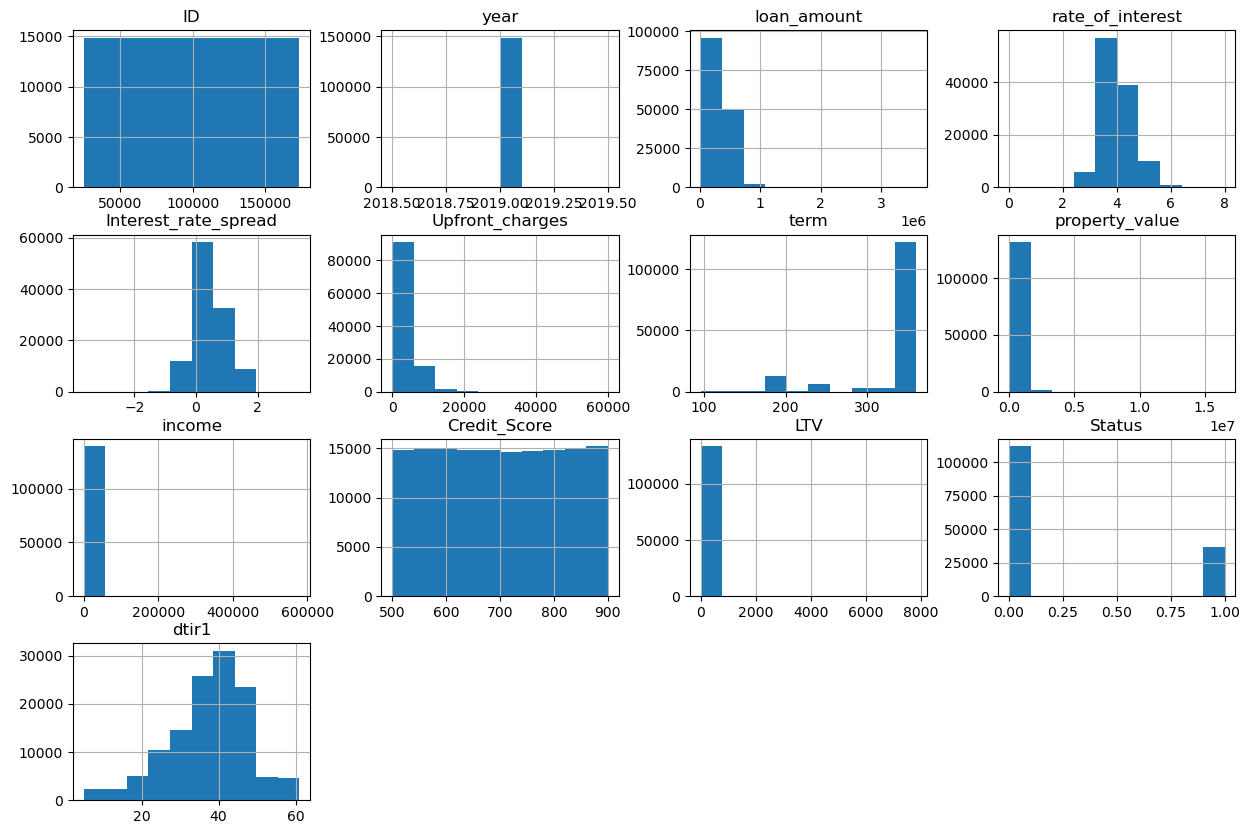

In [57]:
df_data.hist(figsize=(15, 10))

ID is a unique identifier of every applicant and therefore likely does not show a meaningful pattern. This feature will be dropped when preprocessing the data. 

The histogram for year is clustered around 2019 only, which is confirmed by the summary statistics we analyzed earlier that showed a min and max of 2019. This means our data is from 2019, and is unlikely to affect the target variable or show a meaningful pattern.

The histogram for loan amount appears to be right-skewed. Most of the loan amounts are clustered toward the left, so there are lots of small loans, with a few larger loans (creating the right tail)

The rate of interest appears to follow a bell-shaped curve, with most loans having an interest rate of 4% and few interest rates that are extremely high or low. This is reflected by the summary statistics where the 25%, 50%, and 75% quartiles are all approximately 4%.

Interest_rate_spread also appears to follow a bell-shaped curve, similar to rate_of_interest. This may be because interest_rate_spread is derived from the difference between the rate_of_interest and a comparison benchmark.

Upfront_charges appears to also be right-skewed, with most of the values clustered towards the left (so a higher number of lower upfront charges), with a few higher upfront charges.

Term seems to be left-skewed, with most values being higher terms.

Property value is right-skewed, with a few properties that are very high in value. Income is also right-skewed. 

The distribution for credit score seems to be uniform/even. There do not seem to be obvious clusters around a particular score range. This may be something to dig into further, as credit scores typically may cluster around a median range in real world settings.

LTV (Loan-to-Value) is also right-skewed. 

Status is our binary categorical variable, with values of either 0 (successfully repaid loan) or 1 (defaulted loan).

dtir1 (Debt-to-Income Ratio) appears to approximately follow a bell-shaped curve, with the mean around 40, with a slight left skew.

Checking Credit Score to analyze its distribution to see if the distribution is actually uniform or if there are any peaks or clusters:

In [58]:
df_data["Credit_Score"].describe()

count    148670.000000
mean        699.789103
std         115.875857
min         500.000000
25%         599.000000
50%         699.000000
75%         800.000000
max         900.000000
Name: Credit_Score, dtype: float64

In [59]:
df_data["Credit_Score"].value_counts(normalize=True)

Credit_Score
763    0.002791
867    0.002778
639    0.002765
581    0.002744
554    0.002738
         ...   
745    0.002220
573    0.002220
743    0.002200
748    0.002179
559    0.002159
Name: proportion, Length: 401, dtype: float64

The above analysis of credit scores shows that there are no hidden clusters and verifies the uniform distribution of the credit score variable, as shown in the histogram

**Creating box plots for each numeric variable**

This allows us to identify potential outliers and understand the spread of the data

In [61]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

#defining the columns that are numeric:
numerical_cols = df_data.select_dtypes(include="number").columns
print(numerical_cols)

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')


In [62]:
n_cols = 3 #defining the number of columns we want in the output figure (number of boxplots per row)
n_rows = math.ceil(len(numerical_cols) / n_cols) 
'''determining the number of rows--distributing the total number of numerical columns across rows with 3 numerical columns per row of the boxplot outputs'''

'determining the number of rows--distributing the total number of numerical columns across rows with 3 numerical columns per row of the boxplot outputs'

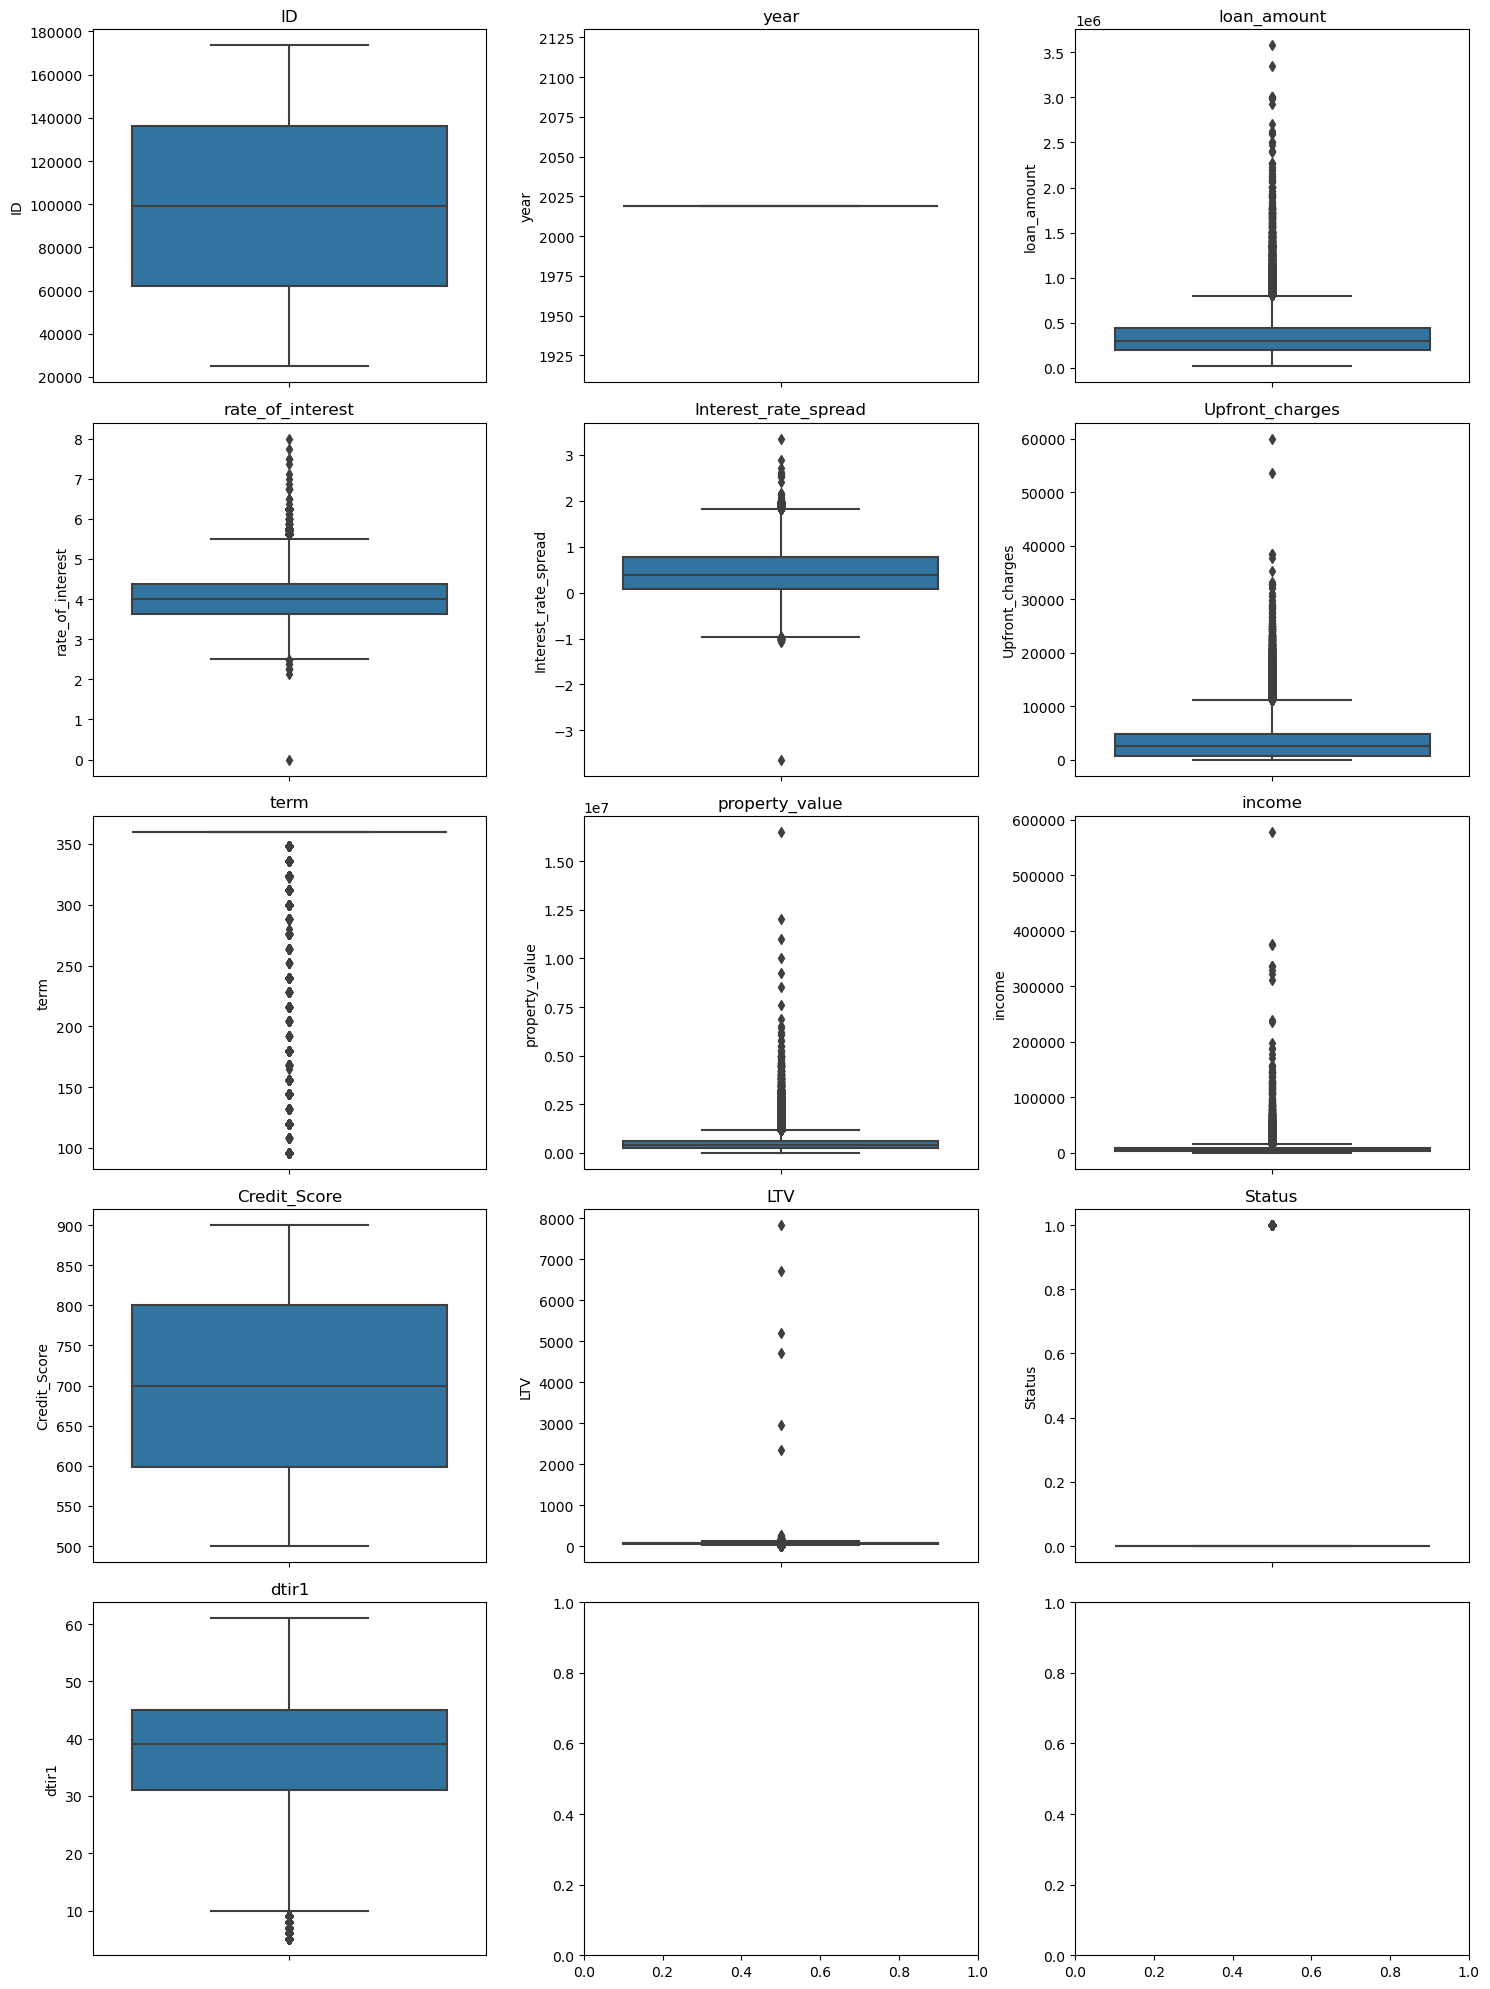

In [63]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows)) 
#fig returns the overall figure which contains all the plots, and axes is each of the graphs

axes = axes.flatten() #making the 2D numpy array into a 1D array so we can apply sns.boxplot and iterate through each subplot one at a time

for axis, col in zip(axes, numerical_cols):
    sns.boxplot(y=df_data[col], ax = axis)
    axis.set_title(col)

plt.tight_layout()
plt.show()



The boxplot for loan_amount verifies our findings from the histogram analysis. The median seems to be closer to the bottom of the box/IQR. The upper whisker is longer than the lower whisker, indicating there is more spread of data across upper quartile. There also seem to be a lot of outliers above the upper end of the range. 

The boxplot for the rate_of_interest variable is largely symmetric as well, but there are many outliers above the 75th percentile (marked by the upper whisker) compared to a few below the 25th percentile. 

Likewise, the boxplot for interest_rate_spread is approximately symmetric, with more upper outliers. 

The boxplot for upfront_charges shows that the median seems to be closer to the bottom of the plot, and the upper tail is longer. There are also more outliers above the upper tail. This matches the right-skew we saw in the histogram.

Property_value seems to show a strong right skew as well, with a small IQR that is closer to the bottom of the plot. This matches the findings in the histogram, where most of the property_values are clustered around lower values. However, there are several outliers, above the upper whisker. 

Income shows similar findings, with a strong right skew, small IQR, and several outliers above the upper whisker.

Credit_score shows a symmetric box plot, and the spread of the upper and lower ends of the range are even. This matches the findings from the histogram, where I found that credit score seems to be uniformly distributed, without clusters around any particular credit score range. 

Loan-to-value seems to have a small IQR and shows a strong right-skew (as did the histogram), with several outliers above the upper whisker. The highest outlier seems to represent a LTV ratio of about 8000%, which is something to investigate, as it much higher than the typical LTV ratio. 


Investigating loan amounts outliers:

In [64]:
df_data.nlargest(10, "loan_amount")[["loan_amount", "rate_of_interest", "Upfront_charges", "Interest_rate_spread", "property_value", "LTV"]]

,loan_amount,rate_of_interest,Upfront_charges,Interest_rate_spread,property_value,LTV
4321,3576500,NaN,NaN,NaN,5208000.0,68.673195
98146,3346500,NaN,NaN,NaN,NaN,NaN
3762,3006500,3.990,60000.00,0.5414,5258000.0,57.179536
54519,3006500,3.125,0.00,-0.3637,5758000.0,52.214311
86408,3006500,NaN,NaN,NaN,3508000.0,85.704105
121640,3006500,NaN,NaN,NaN,NaN,NaN
114333,2986500,3.990,12328.84,-0.2733,5508000.0,54.221133
42200,2926500,NaN,NaN,NaN,4878000.0,59.993850
68421,2706500,NaN,NaN,NaN,4508000.0,60.037711
128145,2626500,NaN,NaN,NaN,NaN,NaN


Although there are outliers significantly higher than the mean loan_amount, these observations also seem to be high-value properties. Additionally, looking at the LTV ratios for some of these observations, they seem to be within a typical range for a mortgage (about 50-70%), suggesting that these are not indications of issues with data quality and are instead likely to be a consequence of financing higher value properties. 

Investigating upfront charges outliers:

In [65]:
df_data.nlargest(20, "Upfront_charges")[["Upfront_charges", "loan_amount", "property_value"]]

,Upfront_charges,loan_amount,property_value
3762,60000.00,3006500,5258000.0
27166,53485.78,1306500,1708000.0
30636,38437.50,1756500,2508000.0
113641,38375.00,1356500,1858000.0
55892,37604.38,1716500,2398000.0
146563,35192.50,1276500,1728000.0
116695,33268.00,856500,1128000.0
136008,32850.00,1096500,1328000.0
125142,32825.25,746500,1298000.0
140825,32647.00,886500,1128000.0


Inspection of the observations with the largest upfront charges shows that these loans are also associated with relatively large loan amounts and property values. This suggests that the high upfront charges may be a consequence of financing larger, higher-valued properties rather than data quality issues.

Investigating the high LTV ratio outliers:

In [66]:
df_data.nlargest(10, "LTV")[["loan_amount", "property_value", "LTV"]]

,loan_amount,property_value,LTV
16951,626500,8000.0,7831.250000
55286,536500,8000.0,6706.250000
47807,416500,8000.0,5206.250000
65238,376500,8000.0,4706.250000
46287,236500,8000.0,2956.250000
123343,186500,8000.0,2331.250000
43348,126500,48000.0,263.541667
27473,66500,28000.0,237.500000
30837,66500,28000.0,237.500000
136154,546500,248000.0,220.362903


The observations with the highest LTV values are associated with unusually low property values relative to their loan amounts, resulting in very high LTV ratios, with the highest exceeding 2,000–7,800%. These values are substantially higher than typical mortgage LTV ratios and may indicate data quality issues or misrecorded property values. These observations should be investigated further before deciding whether to remove them from the dataset.

The property_values associated with the highest LTV values also seem to be much lower than the mean property value (around 497,893.5), with loan amounts higher than the mean loan_amount (331,117.7). This discrepancy explains the inflated Loan-to-Value ratio. 

**Analyzing correlations**

Correlation heatmap for numerical variables

We can drop ID and year because ID is a unique identifier for each row (and therefore is not meaningful in predicting the target) and the year is uniform across all rows in the dataset (2019)

In [67]:
df_data.drop(columns=["ID", "year"], inplace=True)

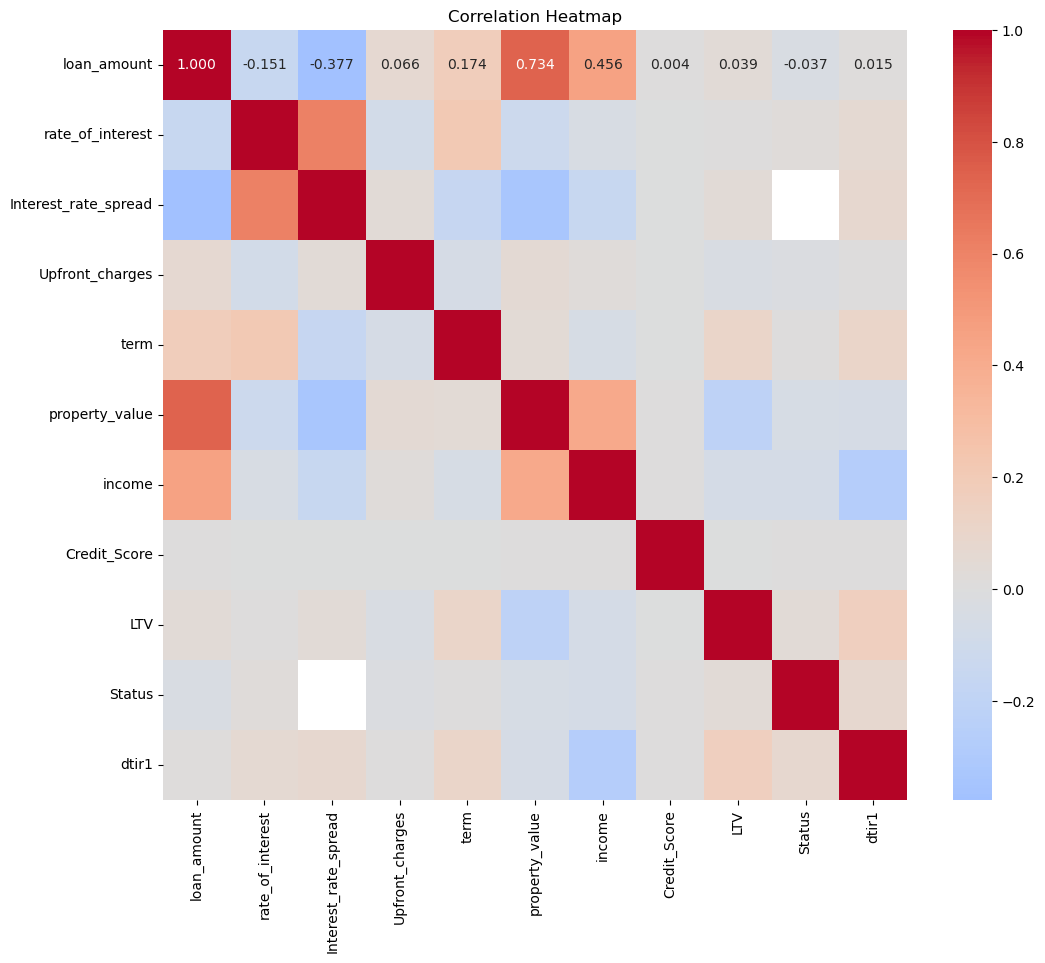

In [68]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f"
)

plt.title("Correlation Heatmap")
plt.show()

We can use the correlation heatmap to examine the linear relationships between different pairs of variables and identify multicolinearity among the predictor variables. 

The heatmap shows that loan_amount and property_value have a strong positive correlation. This suggests that the variables move closely together, and may introduce some degree of multicollinearity if they are both used for the model. This positive correlation also reinforces the trend we observed earlier, where higher loan_amount often corresponded with higher property values.

Rate_of_interest and interest_rate_spread seem to have a strong positive correlation, indicating that loans with higher interest rates tend to have a higher interest rate spread as well. 

Loan_amount and income seem to be positively and moderately correlated, and term and rate_of_interest seem to be mildly positively correlated. Income and property_value are also moderately and positively correlated.

There seem to be weaker positive correlations between other pairs of variables such as rate_of_interest and term. Most of the remaining feature pairs exhibit relatively weak correlations. This suggests that, aside from a few moderately to strongly correlated variables, the dataset does not appear to contain widespread multicollinearity based on pairwise correlation alone.

Using the correlation heatmap, we can analyze pairwise linear relationships and identify potential multicollinearity. However, analyzing pairwise correlations alone does not fully capture multicollinearity among multiple variables. To assess multicollinearity among different variables together, we can calculate the Variance Inflation Factor when we are fitting the logistic regression model (ensemble and tree-based models are generally more resistant to multicollinearity)

**Analyzing how the feature variables relate to the target**

Relationship between numerical feature variables and the target (loan status):

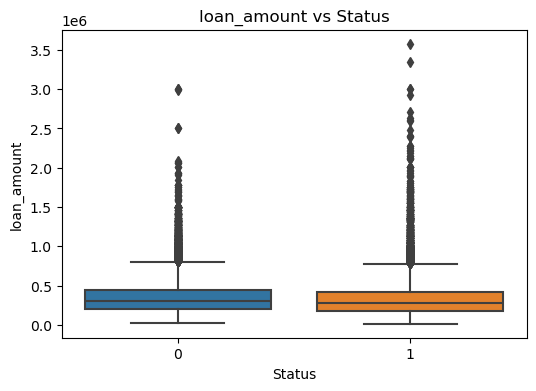

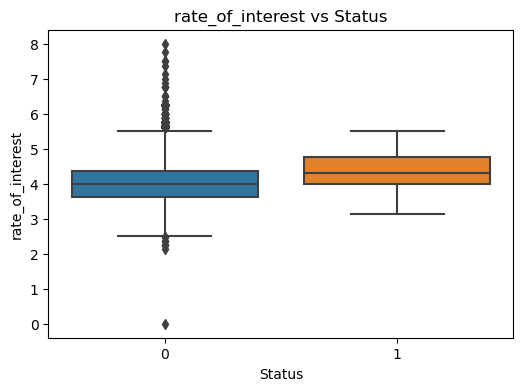

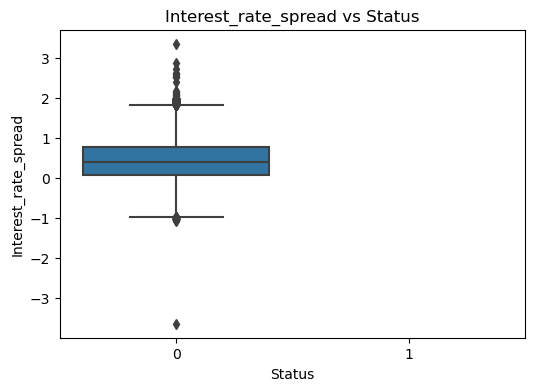

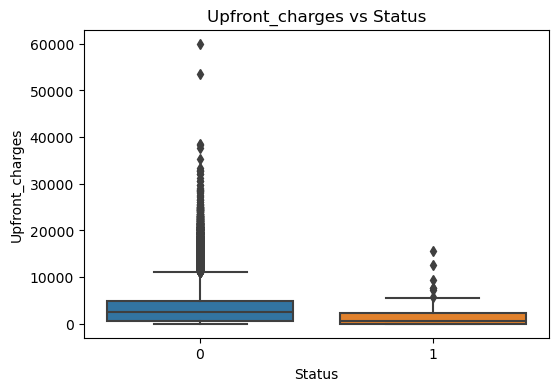

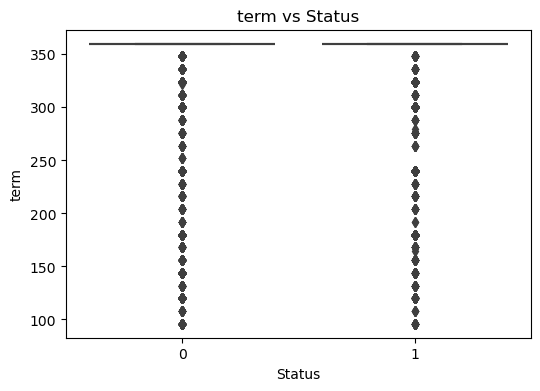

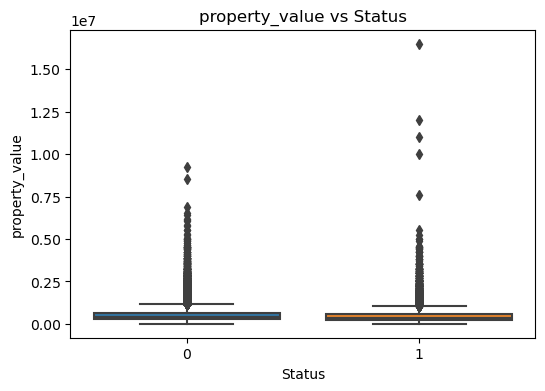

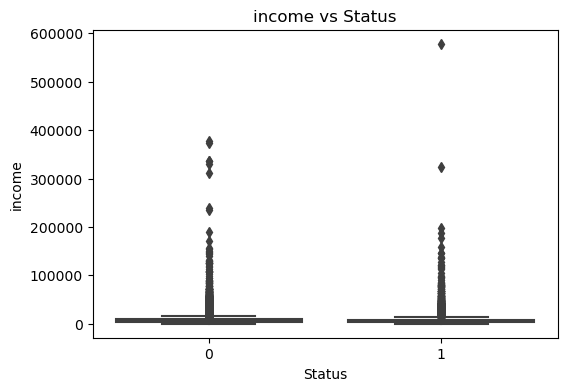

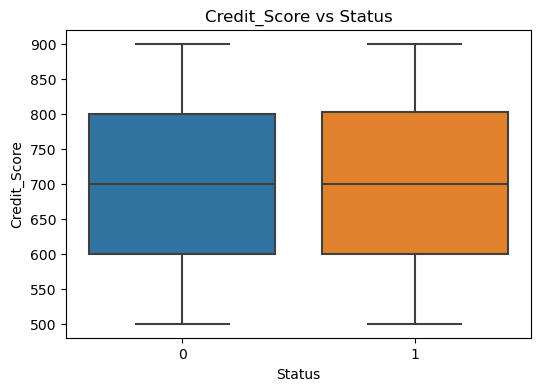

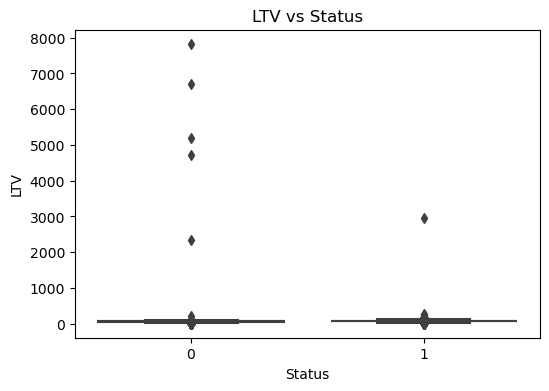

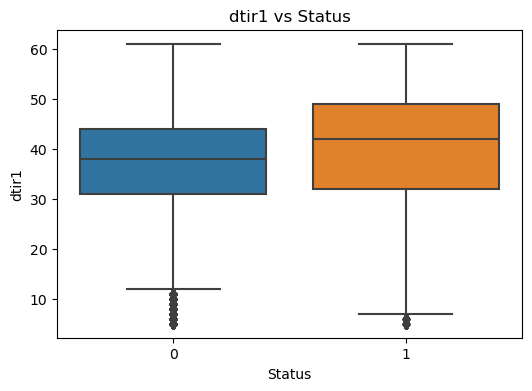

In [69]:
numeric_cols = df_data.select_dtypes(include="number").drop(columns=["Status"]) #don't include the target variable

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Status", y=col, data=df_data)
    plt.title(f"{col} vs Status")
    plt.show()

    

We can analyze how each numeric variable varies differs based on the value of status (0 = non-default, 1 = default). The box plots allow us to examine how the data skew and outlier trends vary for each variable across each status value (default or non-default)

Loan_amount seems to have outliers above the upper-tail across both Status categories, but rows with Status = 1 (defaulted loans) seem to have higher upper outlier values. This suggests that some larger loan amounts are associated with defaults. 

Rate_of_interest seems to have a higher spread and more extreme upper outliers for non-defaults. The interest rate range for defaults seems to be smaller but defaults seem to have a higher median rate of interest, which is consistent with the fact that lenders typically charge greater interest rates for higher risk applicants. 

The boxplot also shows an interesting observation: interest_rate_spread seems to only be calculated for non-defaulted loans, while all defaulted loans are missing this attribute. 

Defaulted loans seem to have smaller upfront charges, and non-defaulted loans show a much heavier right-skew with more extreme upper outliers for upfront charges.

The median property value seems to be similar across defaults and non-defaults, but defaulted loans seem to have higher upper outliers for the property_value variable. Likewise, income seems to have a similar distribution and median value across both groups, but the defaulted group has a few more extreme outliers. 

The distribution of credit score across defaulted and non-defaulted loans seems to be even. This is interesting as we typically might expect credit scores to be generally lower for defaulted loans. 

The loan-to-value variable seems to be more heavily right-skewed across non-defaults with more extreme upper outliers compared to the default group. 

Finally, defaults (status = 1) seem to have a higher median debt-to-income ratio compared to non-defaults (status = 0), though the distribution is relatively similar. This aligns with real-world expectations, as a greater debt-to-income ratio typically indicates a higher risk applicant. 


**Relationship between categorical variables and target**

We will analyze the distribution of each categorical variable by loan status. This allows us to examine how each variable differs across the non-default and default groups. We can use this analysis to identify which categories are most prevalent within each loan status and determine whether certain categories appear more frequently among defaulted or non-defaulted loans.

In [75]:
#Analyzing distribution of categorical variables within each loan status category
categorical_cols = df_data.select_dtypes('object').columns
for col in categorical_cols:
    display(pd.crosstab(df_data["Status"], df_data[col], normalize="index"))

loan_limit,cf,ncf
Status,,
0,0.939179,0.060821
1,0.907321,0.092679


Gender,Female,Joint,Male,Sex Not Available
Status,,,,
0,0.182253,0.298721,0.278985,0.240041
1,0.186905,0.216518,0.302710,0.293867


approv_in_adv,nopre,pre
Status,,
0,0.835620,0.164380
1,0.867163,0.132837


loan_type,type1,type2,type3
Status,,,
0,0.780123,0.121306,0.098571
1,0.703485,0.195748,0.100767


loan_purpose,p1,p2,p3,p4
Status,,,,
0,0.228657,0.019574,0.374674,0.377095
1,0.244099,0.029587,0.382363,0.343951


...

co-applicant_credit_type,CIB,EXP
Status,,
0,0.541627,0.458373
1,0.374273,0.625727


age,25-34,35-44,45-54,55-64,65-74,<25,>74
Status,,,,,,,
0,0.132945,0.227696,0.235390,0.215226,0.135436,0.00848,0.044827
1,0.116578,0.200582,0.229123,0.231126,0.152886,0.01062,0.059085


submission_of_application,not_inst,to_inst
Status,,
0,0.387661,0.612339
1,0.253190,0.746810


Region,North,North-East,central,south
Status,,,,
0,0.516830,0.007668,0.056252,0.419250
1,0.459101,0.010262,0.065368,0.465269


Security_Type,Indriect,direct
Status,,
0,0.000000,1.000000
1,0.000901,0.999099


Looking at the distribution of loan_limit broken down by status value, we can see that across both Status types (0 and 1), conforming loans are more prevalent than non-conforming loans, though the frequency of non-confirming loans is higher for the default category compared to the non-default category. 

Each gender seems to be overall evenly distributed across both the default and non-default categories. The non-default status is slightly dominated by the joint and male gender categories, while the default status is dominated by male and sex not available.

Overall, the proportion of preapproved loans and non-preapproved loans is fairly consistent across both non-defaults and defaults, but the default category does have a slightly higher proportion of non-preapproved loans and a lower proportion of pre-approved loans compared to the non-default category.

Likewise, the distribution of loan type is fairly consistent across both status groups, with type1 loans dominating. However, defaulted loans see a higher proportion of type2 loans and a lower proportion of type1 loans relative to non-defaulted loans. 

Loan purpose seems to be consistent across both status groups.

Credit-worthiness is also fairly consistent across both status groups, but the proportion of l2 credit-worthiness is higher for the defaulted group compared to the non-default group. 

Across both status groups, non-open credit loans dominate, indicating that the dataset mostly contains non-open credit loans (ex: car loans, mortgages).

Non-business and commercial loans tend to dominate overall across both groups, but the default group has a slightly higher proportion of business/commercial loans compared to the non-default group.

Across both groups, most loans do not have negative ammortization, but the default group has more negative ammortization loans than the non-default group.

The proportion of interest-only vs non-interest only loans is consistent across both status groups. The proportion of lump-sum vs non-lump sum payments is fairly consistent across both status groups as well.

The non-default group has no manufactured homes and is entirely composed of site built loans, while the default group has a few manufactured homes. 

Across both status groups, the occupancy type is fairly consistent.

The distribution of the secured_type (home vs land) is also fairly consistent across both status groups, with the non-default group having no loans secured by land.

The number of units in the property being financed is also approximately even across both status groups, but the proportions for 2 unit and 3 unit are slightly higher for the default group.

Credit type seems to vary across the different status groups. While Equifax dominates the default group, it is the lowest proportion among the non-default group. CIB, CRIF, and EXP seem to be more prevalent in the non-default group compared to the default group.

Age is fairly consistent across both status groups. 

Overall, many of the categorical variables seem to overall be consistently distributed across both status groups. The next step of the 